In [1]:
from scdesigner.datasets import pancreas

example_sce = pancreas()
example_sce

AnnData object with n_obs × n_vars = 2087 × 100
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'cell_type', 'sizeFactor', 'pseudotime'
    var: 'highly_variable_genes'
    uns: 'X_name', 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'counts', 'cpm', 'logcounts', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

# PNMF

In [2]:
from scdesigner.simulators import PositiveNMF
from scdiagnostics import compare_histogram, compare_umap
import altair
altair.renderers.enable('png')

RendererRegistry.enable('png')

In [3]:
formula = "~ bs(pseudotime, degree=5)"
model = PositiveNMF(formula, maxIter=500, epochs=50, lr=.1)
model.fit(example_sce)

In [4]:
model.parameters["W"]

,0,1,2
Pyy,0.342549,0.000000,0.045901
Iapp,0.384612,0.000000,0.000000
Chgb,0.000000,0.000000,0.263410
Rbp4,0.205598,0.000000,0.109275
Spp1,0.000000,0.149471,0.000000
...,...,...,...
Ffar2,0.000000,0.036868,0.066497
Hes6,0.000000,0.128671,0.000000
Serpinh1,0.000000,0.119898,0.000000
Npy,0.054516,0.000000,0.000000


In [5]:
model

In [6]:
model.predict()["a"]

,0,1,2
AAACCTGAGAGGGATA,4.614731,3.634608,6.095312
AAACCTGGTAAGTGGC,3.547870,4.923758,3.854005
AAACGGGCAAAGAATC,5.084550,3.395873,6.533628
AAACGGGGTACAGTTC,6.457448,3.158064,6.311361
AAACGGGGTGAAATCA,3.418207,5.191835,3.398690
...,...,...,...
TTTGGTTTCACTTACT,2.907413,4.528250,1.713298
TTTGGTTTCCTTTCGG,5.399422,3.293187,6.681844
TTTGTCAAGAATGTGT,4.749389,3.553513,6.248546
TTTGTCAAGTGACATA,4.145186,4.027615,5.366181


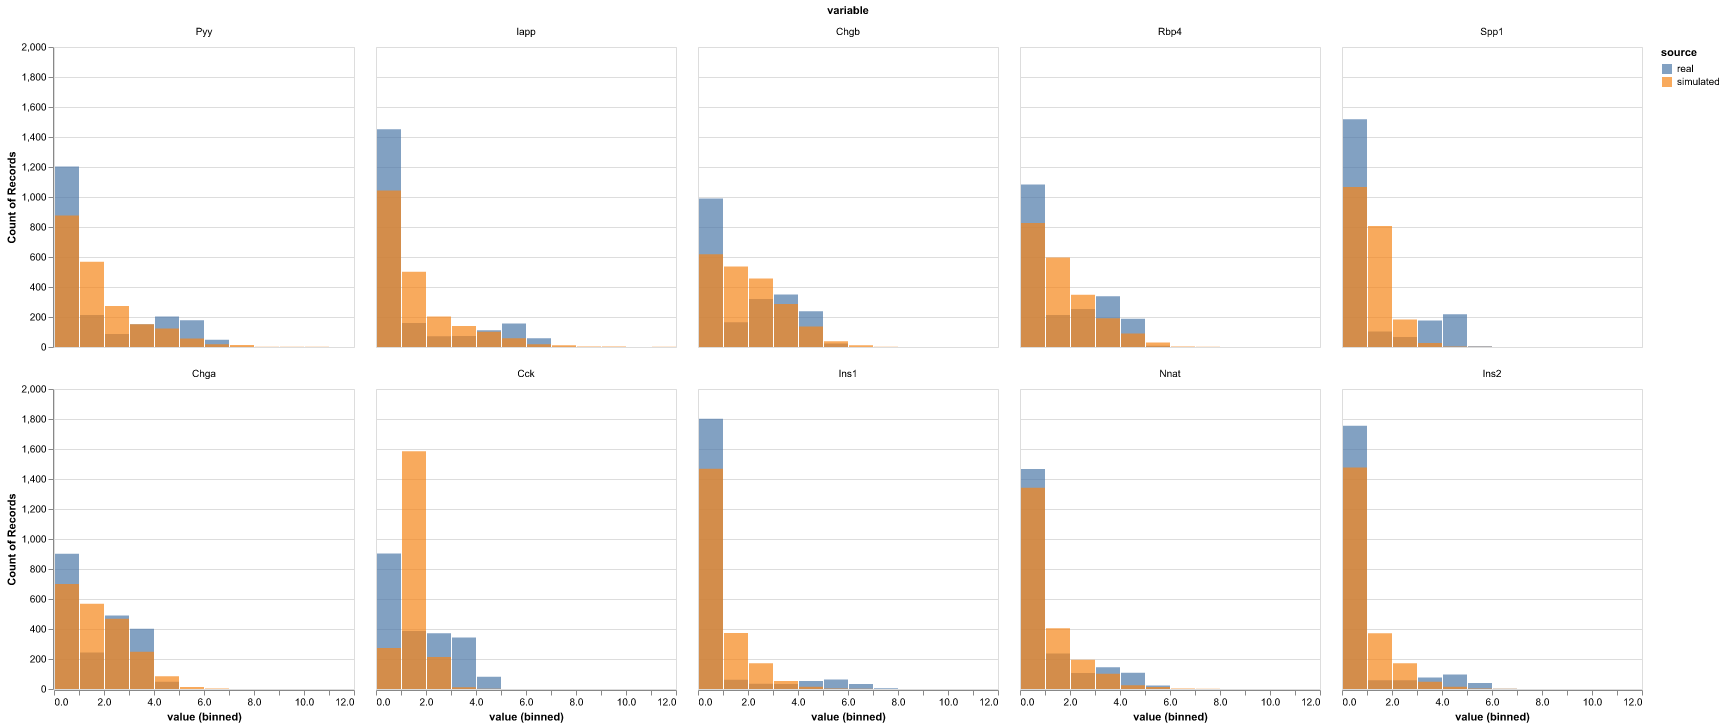

(alt.Chart(...),
           source variable     value
 0           real      Pyy  4.644391
 1           real      Pyy  0.693147
 2           real      Pyy  0.000000
 3           real      Pyy  5.549076
 4           real      Pyy  0.693147
 ...          ...      ...       ...
 20865  simulated     Ins2  0.000000
 20866  simulated     Ins2  1.386294
 20867  simulated     Ins2  1.609438
 20868  simulated     Ins2  0.000000
 20869  simulated     Ins2  0.000000
 
 [41740 rows x 3 columns])

In [7]:
import numpy as np
sample = model.sample(example_sce.obs)
compare_histogram(example_sce, sample)

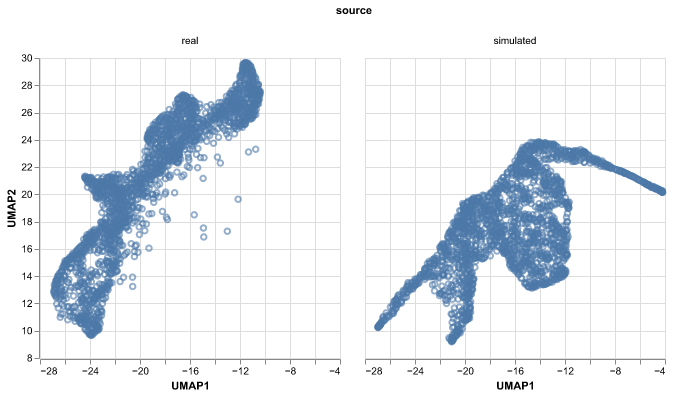

In [8]:
compare_umap(example_sce, sample)

# NB Regression

In [9]:
from scdesigner.simulators import NegBinCopula

formula = "~ bs(pseudotime, degree=5)"
model = NegBinCopula(formula)
model.fit(example_sce)

Epoch 106/500, Loss: 1.8689, Val Loss: 1.8744


Estimating copula correlation: 100%|██████████| 3/3 [00:01<00:00,  2.24it/s]


In [10]:
model

In [11]:
model.parameters["marginal"]["mean"]

,Pyy,Iapp,Chgb,Rbp4,Spp1,Chga,Cck,Ins1,Nnat,Ins2,...,Nkx6-1,Fxyd3,Hn1,Smarcd2,Pdia6,Ffar2,Hes6,Serpinh1,Npy,1110012L19Rik
Intercept,-0.551517,-3.535414,1.118385,-0.402925,4.162090,-0.279437,-2.441890,-1.941580,-2.311142,-3.709440,...,0.610628,0.382870,1.623419,-0.163137,0.917947,-1.087264,-0.642958,1.758552,-2.332870,-0.005417
"bs(pseudotime, degree=5)[1]",2.077345,12.568758,-24.038961,0.695279,1.082457,-18.795385,-2.717345,2.689295,2.257557,3.767419,...,-1.830791,-4.881321,-2.456025,1.571203,1.620261,3.271333,4.872200,-1.255564,-18.601933,-5.611063
"bs(pseudotime, degree=5)[2]",-5.889585,-11.043594,16.936449,-7.976719,-3.857890,18.539099,21.219940,-4.950737,5.056210,-1.526779,...,4.877627,7.956298,7.422340,5.593390,-1.522496,-1.251538,3.158862,3.757995,25.056904,8.615699
"bs(pseudotime, degree=5)[3]",6.068821,4.045277,-0.583512,7.594986,-18.587143,-2.180726,-4.350729,3.484628,-4.947739,-4.191910,...,-2.094238,-4.115128,-7.678006,-3.489986,-3.434392,6.844220,-2.184483,-7.591491,-23.927870,-0.435034
"bs(pseudotime, degree=5)[4]",7.640328,8.186497,3.446071,4.778095,2.533347,4.749980,5.746813,-3.455665,6.323394,4.970713,...,1.178733,2.717614,1.280909,0.285032,1.252679,-0.464607,2.480907,-1.017674,-2.150559,-2.080508
"bs(pseudotime, degree=5)[5]",4.945756,9.885473,1.159818,3.827159,-6.980800,2.646250,2.843375,9.829298,7.101221,9.253352,...,1.207467,-0.693687,-1.524941,-1.088959,1.787317,1.284415,0.365675,-2.087962,6.146428,-0.684123


In [12]:
model.predict(example_sce.obs)["mean"]

array([[4.8359703e+01, 2.0540886e+00, 5.4226078e+01, ..., 4.4598088e-01,
        1.1715549e-03, 1.1883272e+00],
       [1.3569819e+00, 8.4083855e-02, 5.4851685e+00, ..., 1.9309026e+00,
        1.3751882e-02, 3.8552742e+00],
       [1.1566875e+02, 1.0120512e+01, 4.2178997e+01, ..., 4.3603563e-01,
        2.2095593e-03, 6.5342897e-01],
       ...,
       [6.4835274e+01, 3.3093462e+00, 5.1239639e+01, ..., 4.3177098e-01,
        1.2573571e-03, 9.8528290e-01],
       [1.3023372e+01, 3.7232831e-01, 5.0327190e+01, ..., 6.2405807e-01,
        1.9578405e-03, 2.3938062e+00],
       [6.0431671e-01, 1.4663319e-01, 2.4606854e-01, ..., 3.7294719e+00,
        1.4131258e-02, 2.1455369e+00]], shape=(2087, 100), dtype=float32)

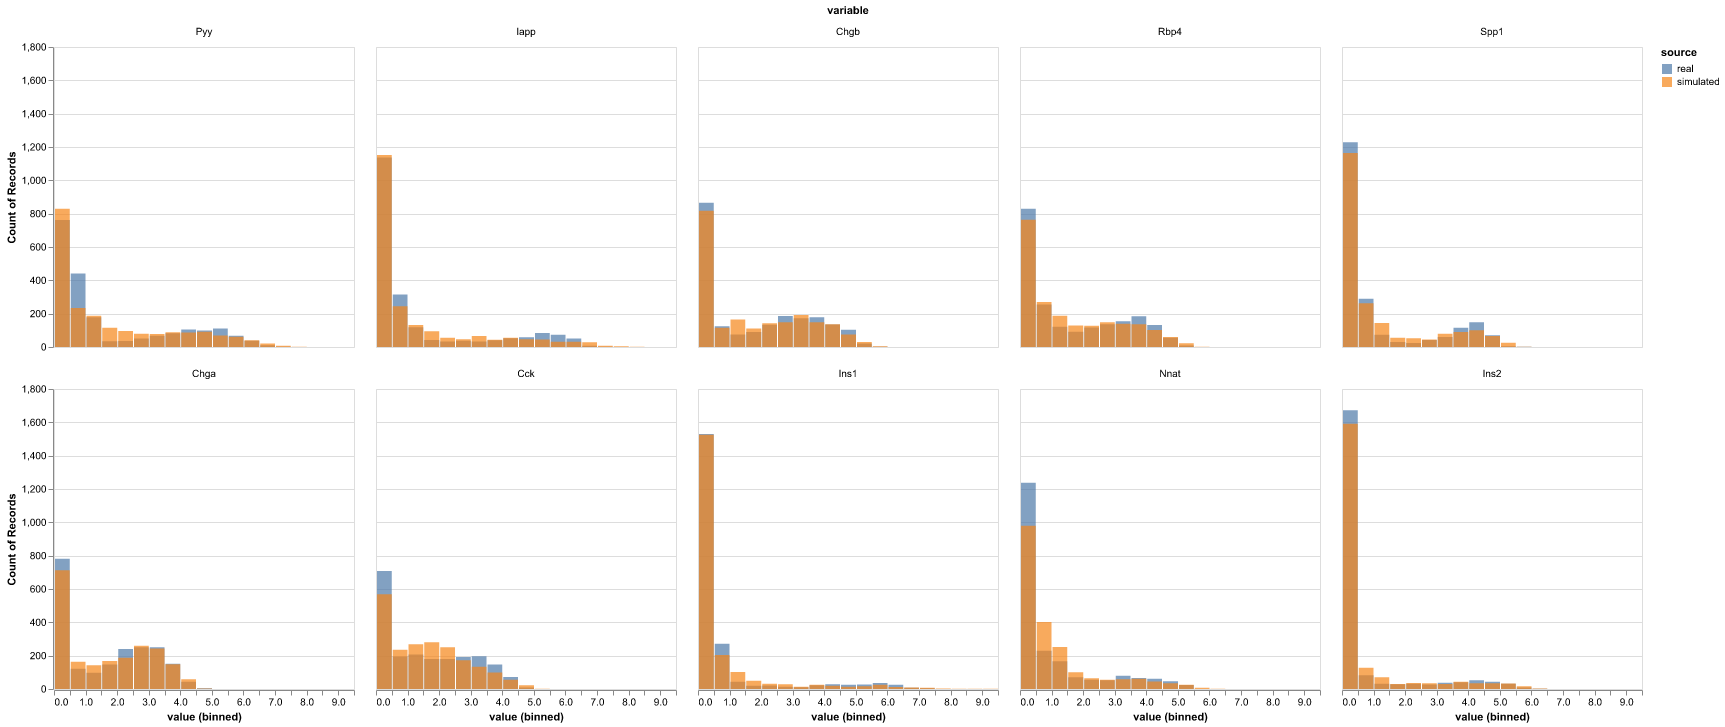

(alt.Chart(...),
           source variable     value
 0           real      Pyy  4.644391
 1           real      Pyy  0.693147
 2           real      Pyy  0.000000
 3           real      Pyy  5.549076
 4           real      Pyy  0.693147
 ...          ...      ...       ...
 20865  simulated     Ins2  0.000000
 20866  simulated     Ins2  0.000000
 20867  simulated     Ins2  0.000000
 20868  simulated     Ins2  0.000000
 20869  simulated     Ins2  0.000000
 
 [41740 rows x 3 columns])

In [13]:
sample = model.sample(example_sce.obs)
compare_histogram(example_sce, sample)

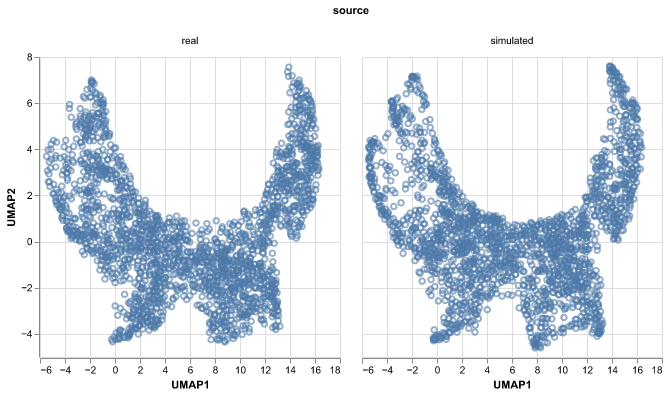

In [14]:
compare_umap(example_sce, sample)

In [15]:
model.parameters["copula"]

{'Intercept':                     Pyy      Iapp      Chgb      Rbp4      Spp1      Chga  \
 Pyy            1.000000  0.096642 -0.136439  0.235381  0.012714 -0.055089   
 Iapp           0.096642  1.000000 -0.037405  0.070563 -0.010884 -0.009439   
 Chgb          -0.136439 -0.037405  1.000000 -0.109318  0.022753  0.129955   
 Rbp4           0.235381  0.070563 -0.109318  1.000000  0.018681 -0.045824   
 Spp1           0.012714 -0.010884  0.022753  0.018681  1.000000  0.050448   
 ...                 ...       ...       ...       ...       ...       ...   
 Ffar2          0.001546  0.019384  0.074579 -0.009808  0.034726  0.031800   
 Hes6           0.018616  0.028912  0.068764  0.005667  0.009683  0.073979   
 Serpinh1       0.070819 -0.035587  0.028097  0.058655  0.051196  0.031375   
 Npy           -0.014275  0.004055  0.033424 -0.001148 -0.012479  0.000340   
 1110012L19Rik  0.015457  0.020205  0.025737  0.048858  0.057182  0.020367   
 
                     Cck      Ins1      Nnat     